In [2]:
import numpy as np
import ee
import geemap

ee.Authenticate()
ee.Initialize()

In [3]:
map = geemap.Map()
map.add_basemap("HYBRID")
center = ee.Geometry.Point([46.439209, 30.949347])
map.centerObject(center, 4)

map

Map(center=[30.949347000000003, 46.439209], controls=(WidgetControl(options=['position', 'transparent_bg'], po…

In [4]:
roi = map.draw_last_feature.geometry()

In [5]:
# Creating a timelist
time_start = ee.Date('2005')
time_end = ee.Date('2010')
time_dif = time_end.difference(time_start, 'year').round()
time_list = ee.List.sequence(0, ee.Number(time_dif).subtract(1)).map(
    lambda x: time_start.advance(x, 'year')
)

# Function for obtaining the date for the spicfic time
def annual(date, col):
  start_date = ee.Date(date)
  end_date = start_date.advance(1, 'year')
  img_sum = col.filterDate(start_date, end_date).sum()
  return img_sum.set('system:time_start', start_date.millis())

In [6]:
# Script in the cell is Demo
ndvi = (
    ee.ImageCollection("MODIS/061/MOD13A2")
    .filterDate(time_start, time_end)
    .select("NDVI")
    .map(lambda x: x.multiply(0.0001).copyProperties(x, ['system:time_start'])
    )
)

ndvi_annual = ee.ImageCollection(time_list.map(lambda x: annual(date=x, col=ndvi)))

In [7]:
# Add one NDVI layer for each year (toggle in the layer manager)
annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

for i in range(5):
    annual_img = ee.Image(annual_list.get(i))
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    map.addLayer(
        annual_img.clip(roi),
        {'bands': ['NDVI'], 'min': -7970.3, 'max': 87319.55, 'palette': ['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b']},
        f'NDVI {year_label}',
        False
    )

map

Map(bottom=27233.0, center=[30.500750980290693, 46.81823730468751], controls=(WidgetControl(options=['position…

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

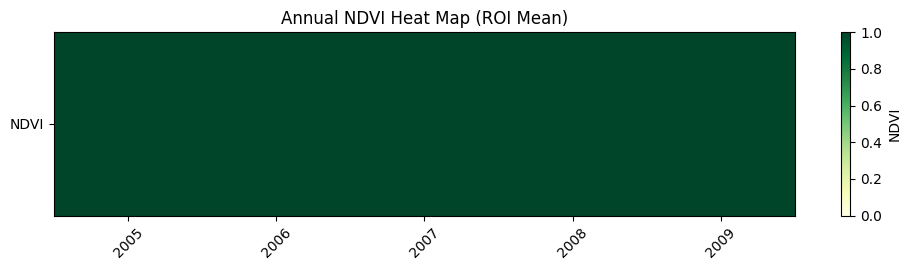

In [8]:
# NDVI HEATMAP (all years in one plot)
import numpy as np
import matplotlib.pyplot as plt

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()
years = []
mean_ndvi = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i))
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    ndvi_value = annual_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=1000,
        maxPixels=1e13
    ).get('NDVI').getInfo()
    if ndvi_value is not None:
        years.append(int(year_label))
        mean_ndvi.append(ndvi_value)

heat = np.array(mean_ndvi, dtype=float).reshape(1, -1)
plt.figure(figsize=(max(10, len(years) * 0.6), 2.8))
im = plt.imshow(heat, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
plt.yticks([0], ['NDVI'])
plt.xticks(range(len(years)), years, rotation=45)
plt.title('Annual NDVI Heat Map (ROI Mean)')
cbar = plt.colorbar(im)
cbar.set_label('NDVI')
plt.tight_layout()
plt.show()

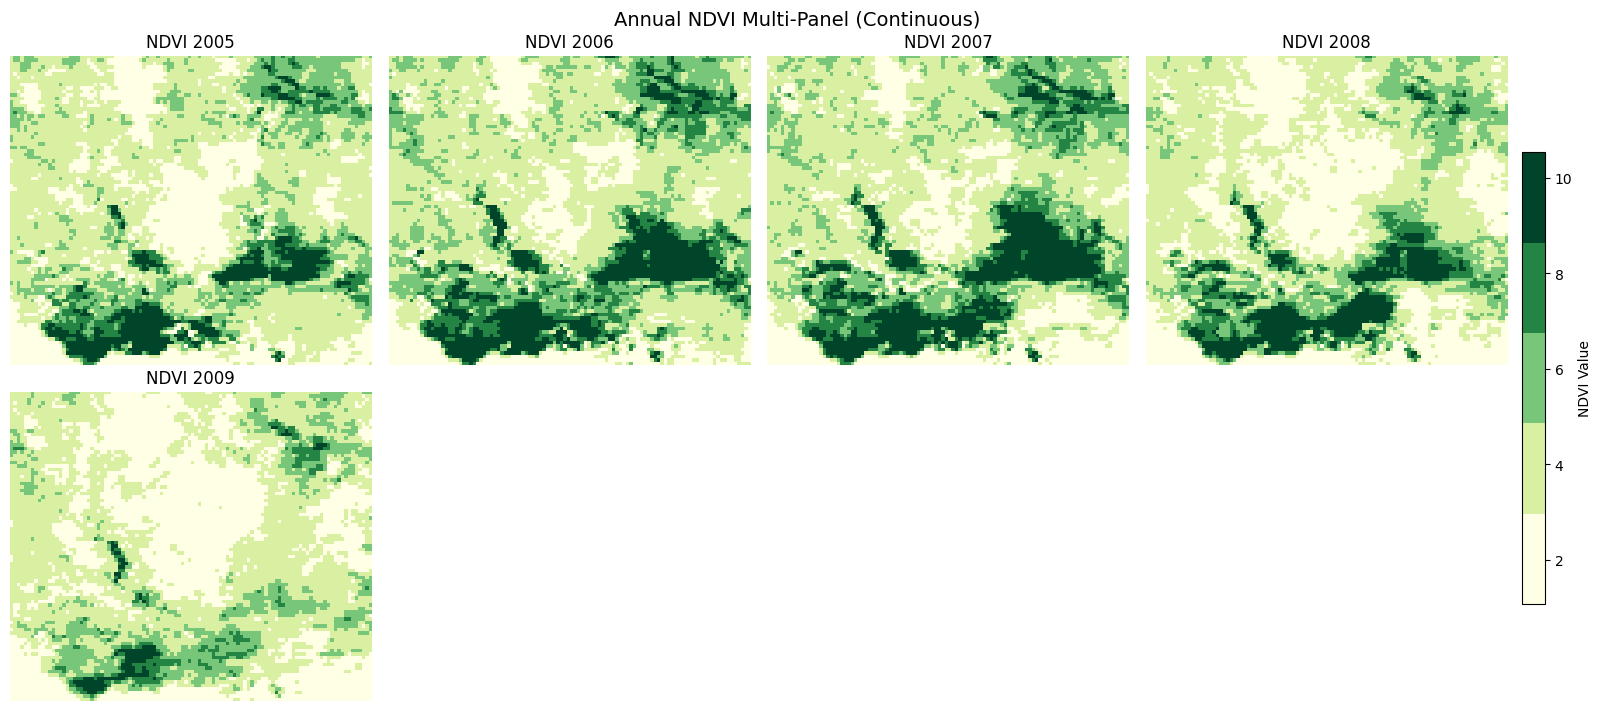

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors


annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

years = []
arrays = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i)).clip(roi)
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    arr = geemap.ee_to_numpy(annual_img, region=roi, scale=1000)
    if arr is None:
        continue
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    years.append(year_label)
    arrays.append(arr)

if not arrays:
    raise ValueError('No NDVI images were converted to arrays. Check ROI and scale.')

n = len(arrays)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

# Define the color palette and min/max values from your specified vis_params
# vis_params = {'bands': ['NDVI'], 'palette': ['#ffffe5', '#d9f0a3', '#78c679', '#238443', '#004529'], 'min': 1.0750700000000002, 'max': 10.533110000000002}
palette = ['#ffffe5', '#d9f0a3', '#78c679', '#238443', '#004529']
cmap_continuous = matplotlib.colors.ListedColormap(palette)
vmin_val = 1.0750700000000002
vmax_val = 10.533110000000002

for idx, (year_label, arr) in enumerate(zip(years, arrays)):
    # Plot the continuous NDVI array directly without classification
    im = axes[idx].imshow(arr, cmap=cmap_continuous, vmin=vmin_val, vmax=vmax_val)
    axes[idx].set_title(f'NDVI {year_label}')
    axes[idx].axis('off')

for idx in range(n, len(axes)):
    axes[idx].axis('off')

# Create a colorbar for the continuous NDVI values
cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.7, pad=0.01)
cbar.set_label('NDVI Value')
fig.suptitle('Annual NDVI Multi-Panel (Continuous)', fontsize=14)
plt.show()

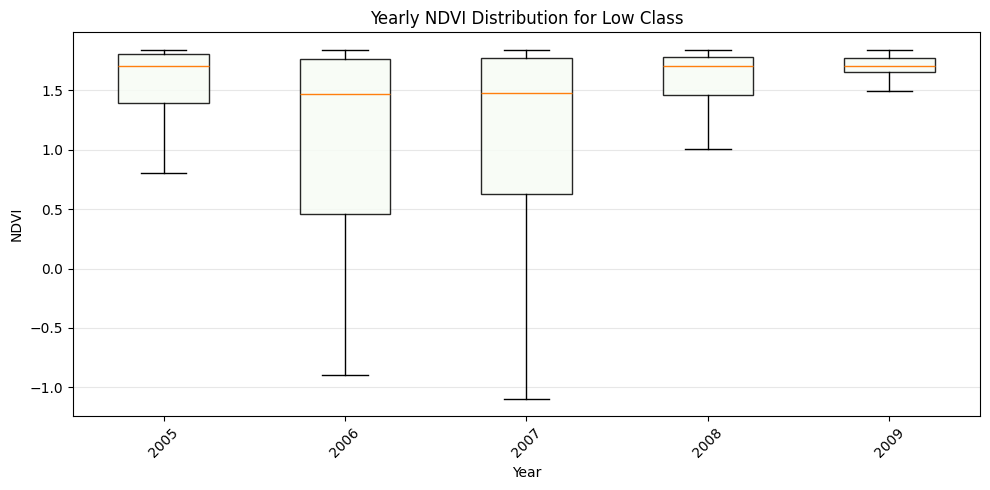

In [10]:
# Boxplot: yearly distribution for the low NDVI class
import numpy as np
import matplotlib.pyplot as plt

palette = ['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b']
n_classes = len(palette)

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

years = []
arrays = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i)).clip(roi)
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    arr = geemap.ee_to_numpy(annual_img, region=roi, scale=1000)
    if arr is None:
        continue
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    arr = np.array(arr, dtype=float)
    valid = arr[np.isfinite(arr)]
    if valid.size == 0:
        continue
    years.append(year_label)
    arrays.append(valid)

if not arrays:
    raise ValueError('No NDVI data found. Check ROI and scale.')

# Build class boundaries globally, then keep only the lowest class per year
all_values = np.concatenate(arrays)
global_min = float(np.nanmin(all_values))
global_max = float(np.nanmax(all_values))
if global_min == global_max:
    global_max = global_min + 1e-6
bin_edges = np.linspace(global_min, global_max, n_classes + 1)
low_min = bin_edges[0]
low_max = bin_edges[1]

low_class_yearly = []
low_year_labels = []
for year_label, vals in zip(years, arrays):
    low_vals = vals[(vals >= low_min) & (vals < low_max)]
    if low_vals.size > 0:
        low_class_yearly.append(low_vals)
        low_year_labels.append(year_label)

if not low_class_yearly:
    raise ValueError('No low-class NDVI pixels found with current class boundaries.')

fig, ax = plt.subplots(figsize=(max(10, len(low_year_labels) * 0.6), 5))
bp = ax.boxplot(low_class_yearly, patch_artist=True, labels=low_year_labels, showfliers=False)

for box in bp["boxes"]:
    box.set_facecolor(palette[0])
    box.set_alpha(0.85)

ax.set_title('Yearly NDVI Distribution for Low Class')
ax.set_xlabel('Year')
ax.set_ylabel('NDVI')
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

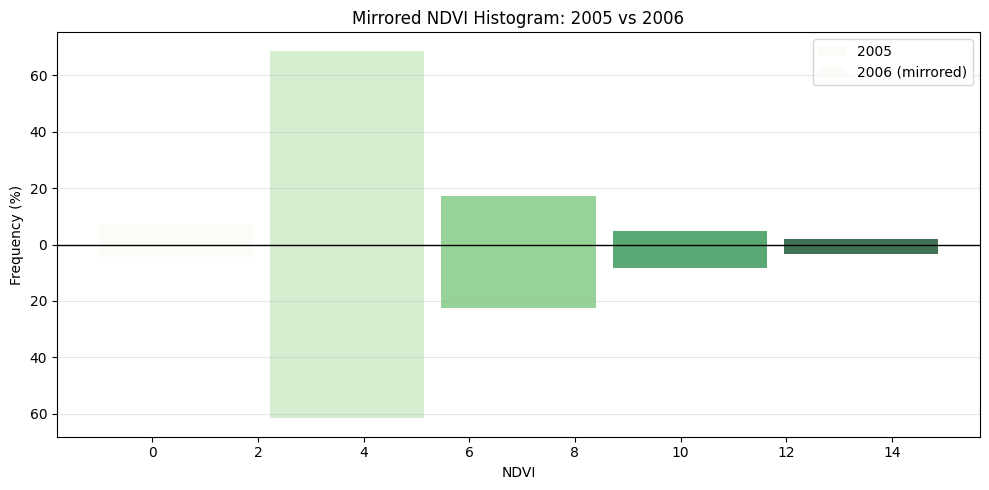

In [84]:
# Mirrored histogram: NDVI comparison between 2005 and 2006
import numpy as np
import matplotlib.pyplot as plt

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

arr_2005 = None
arr_2006 = None

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i)).clip(roi)
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    if year_label not in ["2005", "2006"]:
        continue
    arr = geemap.ee_to_numpy(annual_img, region=roi, scale=1000)
    if arr is None:
        continue
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    vals = np.array(arr, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        continue
    if year_label == "2005":
        arr_2005 = vals
    elif year_label == "2006":
        arr_2006 = vals

if arr_2005 is None or arr_2006 is None:
    raise ValueError('Could not find valid NDVI data for year 2005 and/or 2006.')

# Common bins for fair comparison - use 5 classes like in pie chart
all_vals = np.concatenate([arr_2005, arr_2006])
vmin = float(np.nanmin(all_vals))
vmax = float(np.nanmax(all_vals))
if vmin == vmax:
    vmax = vmin + 1e-6
n_classes = 5
bin_edges = np.linspace(vmin, vmax, n_classes + 1)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
bin_w = bin_edges[1] - bin_edges[0]

h2005, _ = np.histogram(arr_2005, bins=bin_edges)
h2006, _ = np.histogram(arr_2006, bins=bin_edges)

# Convert to percentage to compare independently of pixel count
p2005 = (h2005 / h2005.sum()) * 100.0 if h2005.sum() > 0 else h2005
p2006 = (h2006 / h2006.sum()) * 100.0 if h2006.sum() > 0 else h2006

# Colors based on YlGn palette (5 classes)
palette = ['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(centers, p2005, width=bin_w * 0.9, color=palette, alpha=0.75, label='2005')
ax.bar(centers, -p2006, width=bin_w * 0.9, color=palette, alpha=0.75, label='2006 (mirrored)')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Mirrored NDVI Histogram: 2005 vs 2006')
ax.set_xlabel('NDVI')
ax.set_ylabel('Frequency (%)')
ax.grid(axis="y", alpha=0.3)
yt = ax.get_yticks()
ax.set_yticklabels([f"{abs(t):.0f}" for t in yt])
ax.legend()
plt.tight_layout()
plt.show()

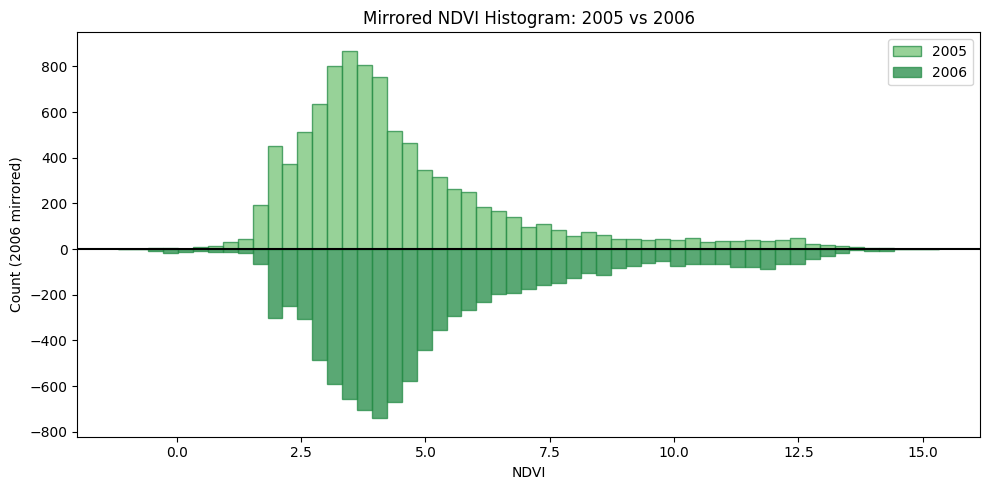

In [12]:
import matplotlib.pyplot as plt
import numpy as np

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

dataset1 = None  # 2005
dataset2 = None  # 2006

for i in range(annual_count):
    img = ee.Image(annual_list.get(i)).clip(roi)
    y = ee.Date(img.get('system:time_start')).format('YYYY').getInfo()
    if y not in ["2005", "2006"]:
        continue

    arr = geemap.ee_to_numpy(img, region=roi, scale=1000)
    if arr is None:
        continue
    if arr.ndim == 3:
        arr = arr[:, :, 0]

    arr = np.array(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        continue

    if y == "2005":
        dataset1 = arr
    else:
        dataset2 = arr

if dataset1 is None or dataset2 is None:
    raise ValueError("Could not find valid NDVI data for 2005 and/or 2006.")

bin_width = 0.3
bins = np.arange(
    np.min([dataset1.min(), dataset2.min()]),
    np.max([dataset1.max(), dataset2.max()]) + bin_width,
    bin_width
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(dataset1, bins=bins, label="2005", color="#74c476", alpha=0.75, edgecolor="#238b45")
ax.hist(dataset2, weights=-np.ones_like(dataset2), bins=bins, label="2006", color="#238b45", alpha=0.75, edgecolor="#238b45")
ax.axhline(0, color="k")
ax.set_title("Mirrored NDVI Histogram: 2005 vs 2006")
ax.set_xlabel("NDVI")
ax.set_ylabel("Count (2006 mirrored)")
ax.legend()
plt.tight_layout()
plt.show()

In [110]:
# Split NDVI (2005) into 5 classes and store in one DataFrame (one column per class)
import numpy as np
import pandas as pd

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

vals_2005 = None
for i in range(annual_count):
    img = ee.Image(annual_list.get(i)).clip(roi)
    y = ee.Date(img.get('system:time_start')).format('YYYY').getInfo()
    if y != "2005":
        continue
    arr = geemap.ee_to_numpy(img, region=roi, scale=1000)
    if arr is None:
        continue
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    arr = np.array(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size > 0:
        vals_2005 = arr
        break

if vals_2005 is None:
    raise ValueError('Could not extract valid NDVI data for year 2005.')

# Create 5 equal-interval classes
n_classes = 5
vmin = float(np.nanmin(vals_2005))
vmax = float(np.nanmax(vals_2005))
if vmin == vmax:
    vmax = vmin + 1e-6
bin_edges = np.linspace(vmin, vmax, n_classes + 1)

class_arrays = []
for c in range(n_classes):
    lo = bin_edges[c]
    hi = bin_edges[c + 1]
    if c < n_classes - 1:
        cls_vals = vals_2005[(vals_2005 >= lo) & (vals_2005 < hi)]
    else:
        cls_vals = vals_2005[(vals_2005 >= lo) & (vals_2005 <= hi)]
    class_arrays.append(np.sort(cls_vals))

# Pad to equal length so all classes can be columns in one DataFrame
max_len = max(len(a) for a in class_arrays)
data = {}
for c, a in enumerate(class_arrays, start=1):
    padded = np.full(max_len, np.nan, dtype=float)
    padded[:len(a)] = a
    data[f"class_{c}"] = padded

ndvi_2005 = pd.DataFrame(data)
ndvi_2005.head()

,class_1,class_2,class_3,class_4,class_5
0,-1.1750,2.0682,5.3097,8.5535,11.8089
1,-1.0088,2.0684,5.3106,8.5633,11.8179
2,-0.5891,2.0684,5.3106,8.5646,11.8210
3,-0.5129,2.0689,5.3106,8.5653,11.8229
4,-0.5129,2.0696,5.3106,8.5676,11.8310


In [111]:
# Split NDVI (2006) into 5 classes and store in one DataFrame (one column per class)


annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

vals_2006 = None
for i in range(annual_count):
    img = ee.Image(annual_list.get(i)).clip(roi)
    y = ee.Date(img.get('system:time_start')).format('YYYY').getInfo()
    if y != "2006":
        continue
    arr = geemap.ee_to_numpy(img, region=roi, scale=1000)
    if arr is None:
        continue
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    arr = np.array(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size > 0:
        vals_2006 = arr
        break

if vals_2006 is None:
    raise ValueError('Could not extract valid NDVI data for year 2006.')

# Create 5 equal-interval classes
n_classes = 5
vmin = float(np.nanmin(vals_2006))
vmax = float(np.nanmax(vals_2006))
if vmin == vmax:
    vmax = vmin + 1e-6
bin_edges = np.linspace(vmin, vmax, n_classes + 1)

class_arrays = []
for c in range(n_classes):
    lo = bin_edges[c]
    hi = bin_edges[c + 1]
    if c < n_classes - 1:
        cls_vals = vals_2006[(vals_2006 >= lo) & (vals_2006 < hi)]
    else:
        cls_vals = vals_2006[(vals_2006 >= lo) & (vals_2006 <= hi)]
    class_arrays.append(np.sort(cls_vals))

# Pad to equal length so all classes can be columns in one DataFrame
max_len = max(len(a) for a in class_arrays)
data = {}
for c, a in enumerate(class_arrays, start=1):
    padded = np.full(max_len, np.nan, dtype=float)
    padded[:len(a)] = a
    data[f"class_{c}"] = padded

ndvi_2006 = pd.DataFrame(data)
ndvi_2006.head()

,class_1,class_2,class_3,class_4,class_5
0,-0.9000,2.2372,5.3759,8.5112,11.6531
1,-0.5547,2.2372,5.3760,8.5143,11.6549
2,-0.5428,2.2382,5.3770,8.5144,11.6559
3,-0.4714,2.2383,5.3770,8.5146,11.6573
4,-0.4357,2.2384,5.3770,8.5146,11.6649


In [217]:
# This is the new way for classyfying the data of nvdi 2005 
# Custom classes (non-equal intervals)
class_5_vals5 = vals_2005[vals_2005 >= 11.5]
class_4_vals5 = vals_2005[(vals_2005 >= 7.5) & (vals_2005 < 11.5)]
class_3_vals5 = vals_2005[(vals_2005 >= 4.5) & (vals_2005 < 7.5)]
class_2_vals5 = vals_2005[(vals_2005 >= 2.5) & (vals_2005 < 4.5)]
class_1_vals5= vals_2005[(vals_2005 >= 0.0) & (vals_2005 < 2.5)]

class_arrays = [
    np.sort(class_1_vals5),
    np.sort(class_2_vals5),
    np.sort(class_3_vals5),
    np.sort(class_4_vals5),
    np.sort(class_5_vals5),
]

# Pad to equal length so all classes can be columns in one DataFrame
max_len = max(len(a) for a in class_arrays)
data = {}
for c, a in enumerate(class_arrays, start=1):
    padded = np.full(max_len, np.nan, dtype=float)
    padded[:len(a)] = a
    data[f"class_{c}"] = padded

ndvi_2005 = pd.DataFrame(data)
ndvi_2005.head()

,class_1,class_2,class_3,class_4,class_5
0,0.0144,2.5003,4.5005,7.5007,11.5015
1,0.1624,2.5005,4.5008,7.5016,11.5015
2,0.2054,2.5010,4.5008,7.5027,11.5111
3,0.3610,2.5022,4.5012,7.5066,11.5182
4,0.3807,2.5026,4.5014,7.5103,11.5192


In [169]:
print(ndvi_2006['class_1'].max())
print(ndvi_2006['class_2'].min())

2.4997999999999996
2.5002999999999997


In [215]:
# This is the new way for classyfying the data of nvdi 2006
# Custom classes (non-equal intervals)
class_5_vals = np.array(vals_2006[vals_2006 >= 11.5])
class_4_vals = np.array(vals_2006[(vals_2006 >= 7.5) & (vals_2006 < 11.5)])
class_3_vals = np.array(vals_2006[(vals_2006 >= 4.5) & (vals_2006 < 7.5)])
class_2_vals = np.array(vals_2006[(vals_2006 >= 2.5) & (vals_2006 < 4.5)])
class_1_vals = np.array(vals_2006[(vals_2006 >= 0.0) & (vals_2006 < 2.5)])

class_arrays = [
    np.sort(class_1_vals),
    np.sort(class_2_vals),
    np.sort(class_3_vals),
    np.sort(class_4_vals),
    np.sort(class_5_vals)
]

# Pad to equal length so all classes can be columns in one DataFrame
max_len = max(len(a) for a in class_arrays)
data = {}
for c, a in enumerate(class_arrays, start=1):
    padded = np.full(max_len, np.nan, dtype=float)
    padded[:len(a)] = a
    data[f"class_{c}"] = padded

ndvi_2006 = pd.DataFrame(data)
ndvi_2006.head()

,class_1,class_2,class_3,class_4,class_5
0,0.0134,2.5008,4.5004,7.5042,11.5136
1,0.0134,2.5010,4.5004,7.5066,11.5138
2,0.0264,2.5095,4.5007,7.5093,11.5138
3,0.0593,2.5100,4.5007,7.5113,11.5330
4,0.0677,2.5110,4.5007,7.5209,11.5453


In [158]:
np.savetxt("D:\\Practice_Projects\\Rain season prospects_Iraq Case Study\\ndvi_20061.csv", ndvi_2006.dropna().values, delimiter=",", fmt="%d")

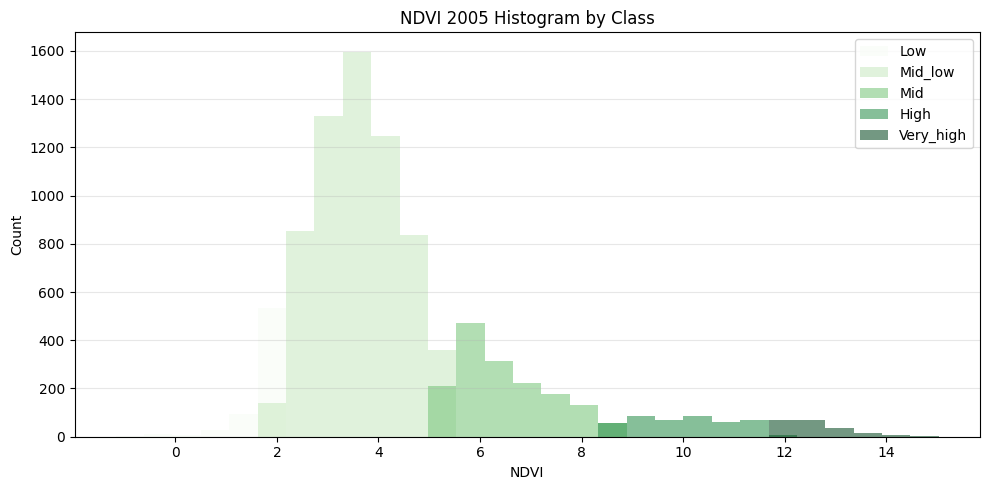

In [131]:
# Histogram of ndvi_2005 classes (one color per column)
import numpy as np
import matplotlib.pyplot as plt

if "ndvi_2005" not in globals():
    raise ValueError('ndvi_2005 DataFrame not found. Run the class-splitting cell first.')

class_cols = [c for c in ndvi_2005.columns if c.startswith('class_')]
if len(class_cols) == 0:
    raise ValueError('No class columns found in ndvi_2005.')

colors = ['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b']
legend_labels = ['Low', 'Mid_low', 'Mid', 'High', 'Very_high']

# Shared bins across all class columns
all_vals = np.concatenate([ndvi_2005[c].dropna().values for c in class_cols if ndvi_2005[c].dropna().size > 0])
if all_vals.size == 0:
    raise ValueError('No numeric values to plot in ndvi_2005.')

bins = np.linspace(float(np.nanmin(all_vals)), float(np.nanmax(all_vals)), 30)

fig, ax = plt.subplots(figsize=(10, 5))
for i, col in enumerate(class_cols):
    vals = ndvi_2005[col].dropna().values
    if vals.size == 0:
        continue
    label = legend_labels[i] if i < len(legend_labels) else col
    ax.hist(vals, bins=bins, alpha=0.55, color=colors[i % len(colors)], label=label)

ax.set_title('NDVI 2005 Histogram by Class')
ax.set_xlabel('NDVI')
ax.set_ylabel('Count')
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

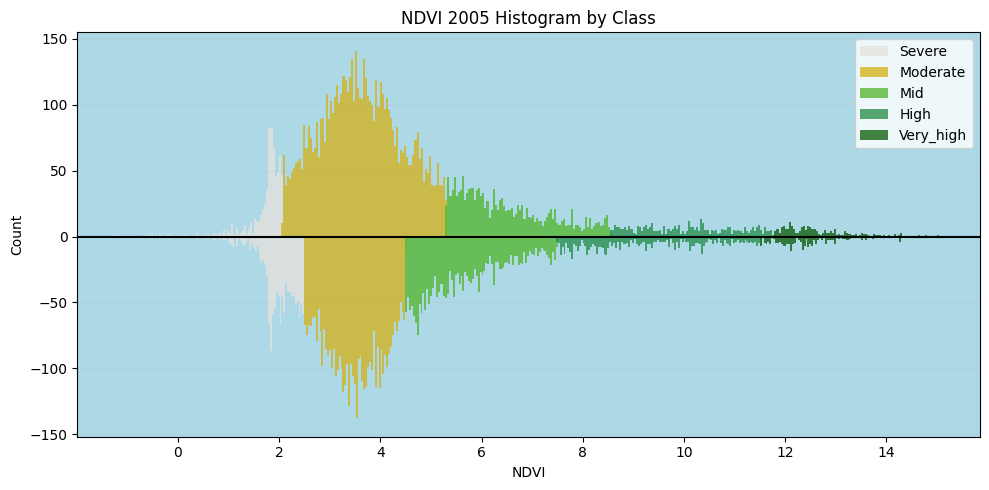

In [210]:
# Histogram of ndvi_2005 classes (one color per column) - legend labels version
import numpy as np
import matplotlib.pyplot as plt

if "ndvi_2005" not in globals():
    raise ValueError('ndvi_2005 DataFrame not found. Run the class-splitting cell first.')

class_cols = [c for c in ndvi_2005.columns if c.startswith('class_')]
if len(class_cols) == 0:
    raise ValueError('No class columns found in ndvi_2005.')

colors = ["#e7e2dc", "#d4b114", "#50b428", "#238b45", "#075A05"]
legend_labels = ['Severe', 'Moderate', 'Mid', 'High', 'Very_high']

all_vals = np.concatenate([ndvi_2005[c].dropna().values for c in class_cols if ndvi_2005[c].dropna().size > 0])
all_vals06 = np.concatenate([ndvi_2006[c].dropna().values for c in class_cols if ndvi_2006[c].dropna().size > 0])
if all_vals.size == 0:
    raise ValueError('No numeric values to plot in ndvi_2005.')

# bin_width = 0.01
# bins = np.arange(
#     np.min([dataset1.min(), dataset2.min()]),
#     np.max([dataset1.max(), dataset2.max()]),
#     bin_width
# )


bins = np.linspace(float(np.nanmin(all_vals)), float(np.nanmax(all_vals)), 400)
bins06 = np.linspace(float(np.nanmin(all_vals06)), float(np.nanmax(all_vals06)), 400)
    
fig, ax = plt.subplots(figsize=(10, 5))
for i, col in enumerate(class_cols):
    vals = ndvi_2005[col].dropna().values
    vals1 = ndvi_2006[col].dropna().values
    if vals.size == 0:
        continue
    label = legend_labels[i] if i < len(legend_labels) else col
    ax.hist(vals,weights=np.ones_like(vals),bins=bins, alpha=0.75, color=colors[i % len(colors)], label=label )
    ax.hist(vals1, weights=-np.ones_like(vals1), bins=bins06, alpha=0.75 , color=colors[i% len(colors) ])


ax.set_title('NDVI 2005 Histogram by Class')
ax.set_xlabel('NDVI')
ax.set_ylabel('Count')
ax.grid(axis="y", alpha=0.1)
ax.axhline(0, color="k")
ax.set_facecolor('lightblue')
ax.legend(legend_labels, loc='upper right')
plt.tight_layout()
plt.show()


In [132]:
print(all_vals.min(), all_vals.max())
print(all_vals06.min(), all_vals06.max())

-1.175 15.0366
-0.8999999999999999 14.784900000000002


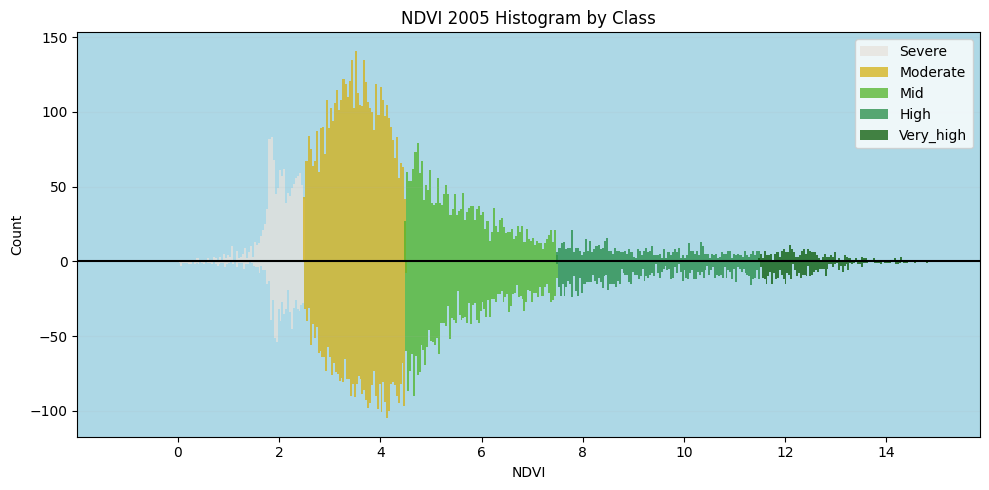

In [ ]:
# Histogram of ndvi_2005 classes (one color per column) - legend labels version
import numpy as np
import matplotlib.pyplot as plt

if "ndvi_2005" not in globals():
    raise ValueError('ndvi_2005 DataFrame not found. Run the class-splitting cell first.')

class_cols = [c for c in ndvi_2005.columns if c.startswith('class_')]
if len(class_cols) == 0:
    raise ValueError('No class columns found in ndvi_2005.')

colors = ["#e7e2dc", "#d4b114", "#50b428", "#238b45", "#075A05"]
legend_labels = ['Severe', 'Moderate', 'Mid', 'High', 'Very_high']

all_vals = np.concatenate([ndvi_2005[c].dropna().values for c in class_cols if ndvi_2005[c].dropna().size > 0])
all_vals06 = np.concatenate([ndvi_2006[c].dropna().values for c in class_cols if ndvi_2006[c].dropna().size > 0])
if all_vals.size == 0:
    raise ValueError('No numeric values to plot in ndvi_2005.')

bin_width = 0.3
bins = np.arange(
    np.min([dataset1.min(), dataset2.min()]) ,
    np.max([dataset1.max(), dataset2.max()]),
    bin_width
)

bins = np.linspace(float(np.nanmin(all_vals)), float(np.nanmax(all_vals)), 400)
bins06 = np.linspace(float(np.nanmin(all_vals06)), float(np.nanmax(all_vals06)), 400)
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(class_1_vals5,weights=np.ones_like(class_1_vals5), bins=bins,    alpha=0.75, color=colors[0 % len(colors)], label=legend_labels[0] )
ax.hist(class_2_vals5,weights=np.ones_like(class_2_vals5), bins=bins,    alpha=0.75, color=colors[1 % len(colors)], label=legend_labels[1] )
ax.hist(class_3_vals5,weights=np.ones_like(class_3_vals5), bins=bins,    alpha=0.75, color=colors[2 % len(colors)], label=legend_labels[2] )
ax.hist(class_4_vals5,weights=np.ones_like(class_4_vals5), bins=bins,    alpha=0.75, color=colors[3 % len(colors)], label=legend_labels[3] )
ax.hist(class_5_vals5,weights=np.ones_like(class_5_vals5), bins=bins,    alpha=0.75, color=colors[4 % len(colors)], label=legend_labels[4] )

ax.hist(class_1_vals, weights=-np.ones_like(class_1_vals), bins=bins06,   color=colors[0% len(colors) ], alpha=0.75 )
ax.hist(class_2_vals, weights=-np.ones_like(class_2_vals), bins=bins06,   color=colors[1% len(colors) ], alpha=0.75 )
ax.hist(class_3_vals, weights=-np.ones_like(class_3_vals), bins=bins06,   color=colors[2% len(colors) ], alpha=0.75)
ax.hist(class_4_vals, weights=-np.ones_like(class_4_vals), bins=bins06,   color=colors[3% len(colors) ], alpha=0.75 )
ax.hist(class_5_vals, weights=-np.ones_like(class_5_vals), bins=bins06,   color=colors[4  % len(colors) ], alpha=0.75)


ax.set_title('NDVI 2005 Histogram by Class')
ax.set_xlabel('NDVI')
ax.set_ylabel('Count')
ax.grid(axis="y", alpha=0.1)
ax.axhline(0, color="k")
ax.set_facecolor('lightblue')
ax.legend(legend_labels, loc='upper right')
plt.tight_layout()
plt.show()

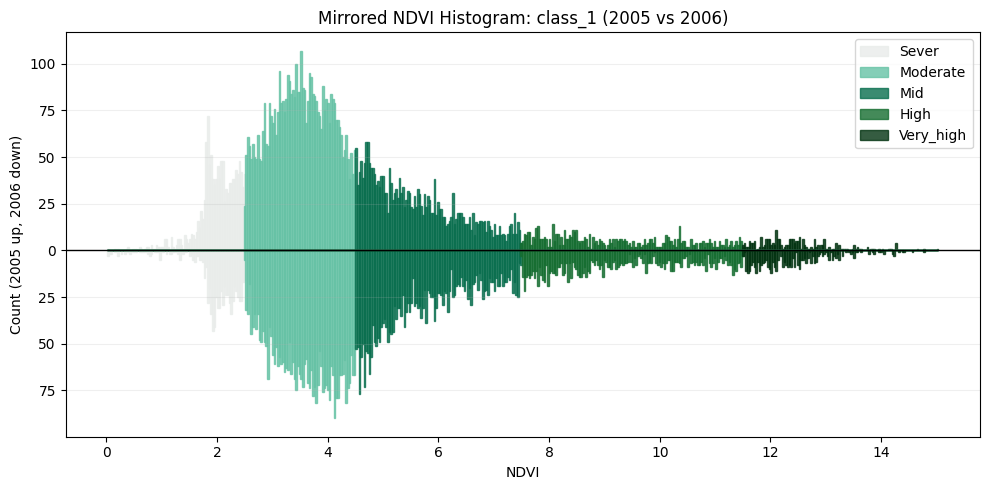

In [227]:
# Mirrored histogram (back-to-back) for class_1 in 2005 vs 2006
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# If arrays are not already defined, build them from DataFrames
try:
    class_1_vals5
    class_1_vals
except NameError:
    ndvi_2005_class_1 = ndvi_2005['class_1'].dropna().values
    ndvi_2005_class_2 = ndvi_2005['class_2'].dropna().values
    ndvi_2006_class_3 = ndvi_2005['class_3'].dropna().values    
    ndvi_2006_class_4 = ndvi_2005['class_4'].dropna().values
    ndvi_2006_class_5 = ndvi_2005['class_5'].dropna().values

    ndvi_2006_class_1 = ndvi_2006['class_1'].dropna().values
    ndvi_2006_class_2 = ndvi_2006['class_2'].dropna().values
    ndvi_2006_class_3 = ndvi_2006['class_3'].dropna().values    
    ndvi_2006_class_4 = ndvi_2006['class_4'].dropna().values    
    ndvi_2006_class_5 = ndvi_2006['class_5'].dropna().values

#arr_2005 = np.asarray(class_1_vals5, dtype=float)
arr_2005_1 = np.asarray(class_1_vals5, dtype=float)
arr_2005_2 = np.asarray(class_2_vals5 , dtype=float)
arr_2005_3 = np.asarray(class_3_vals5, dtype=float)
arr_2005_4 = np.asarray(class_4_vals5, dtype=float)
arr_2005_5 = np.asarray(class_5_vals5, dtype=float)

arr_2006_1 = np.asarray(class_1_vals, dtype=float)
arr_2006_2 = np.asarray(class_2_vals, dtype=float)
arr_2006_3 = np.asarray(class_3_vals, dtype=float)
arr_2006_4 = np.asarray(class_4_vals, dtype=float)
arr_2006_5 = np.asarray(class_5_vals, dtype=float)

#arr_2005 = np.asarray(class_1_vals5, dtype=float)
#arr_2006 = np.asarray(class_1_vals, dtype=float)

all_vals = np.concatenate([arr_2005_1, arr_2005_2, arr_2005_3, arr_2005_4, arr_2005_5, arr_2006_1, arr_2006_2, arr_2006_3, arr_2006_4, arr_2006_5])
bin_edges = np.linspace(all_vals.min(), all_vals.max(), 500)

h20051, _ = np.histogram(arr_2005_1, bins=bin_edges)
h20052, _ = np.histogram(arr_2005_2, bins=bin_edges)
h20053, _ = np.histogram(arr_2005_3, bins=bin_edges)
h20054, _ = np.histogram(arr_2005_4, bins=bin_edges)
h20055, _ = np.histogram(arr_2005_5, bins=bin_edges)

h20061, _ = np.histogram(arr_2006_1, bins=bin_edges)
h20062, _ = np.histogram(arr_2006_2, bins=bin_edges)
h20063, _ = np.histogram(arr_2006_3, bins=bin_edges)
h20064, _ = np.histogram(arr_2006_4, bins=bin_edges)
h20065, _ = np.histogram(arr_2006_5, bins=bin_edges)

centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
widths = np.diff(bin_edges)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(centers, h20051, width=widths, color="#e9ecea", alpha=0.8, label='Sever', edgecolor="#e9ecea")
ax.bar(centers, h20052, width=widths, color="#66c2a5", alpha=0.8, label='Moderate', edgecolor="#66c2a5")
ax.bar(centers, h20053, width=widths, color="#096e4e", alpha=0.8, label='Mid', edgecolor="#096e4e")
ax.bar(centers, h20054, width=widths, color="#156d30", alpha=0.8, label='High', edgecolor="#156d30")
ax.bar(centers, h20055, width=widths, color="#023311", alpha=0.8, label='Very_high', edgecolor="#023311")
ax.bar(centers, -h20061, width=widths, color="#e9ecea", alpha=0.8, edgecolor="#e9ecea")
ax.bar(centers, -h20062, width=widths, color="#66c2a5", alpha=0.8, edgecolor="#66c2a5")
ax.bar(centers, -h20063, width=widths, color="#096e4e", alpha=0.8, edgecolor="#096e4e")
ax.bar(centers, -h20064, width=widths, color="#156d30", alpha=0.8, edgecolor="#156d30")
ax.bar(centers, -h20065, width=widths, color="#023311", alpha=0.8, edgecolor="#023311")

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Mirrored NDVI Histogram: class_1 (2005 vs 2006)')
ax.set_xlabel('NDVI')
ax.set_ylabel('Count (2005 up, 2006 down)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(abs(y))}'))
ax.grid(axis='y', alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()